# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [21]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

pollinations_api_key = os.getenv('POLLINATIONS_API_KEY')
if pollinations_api_key:
    print(f"Pollinations API Key exists and begins {pollinations_api_key[:8]}")
else:
    print("Pollinations API Key not set")
    
MODEL = "gpt-5.4-mini"
openai = OpenAI()
pollinationsai = OpenAI(
    base_url="https://gen.pollinations.ai/v1",
    api_key=pollinations_api_key
)

DB = "prices.db"

OpenAI API Key exists and begins sk-proj-
Pollinations API Key exists and begins sk_iM3hc


In [4]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [5]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [6]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [7]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [8]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [10]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [9]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this Svelte app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use gpt-image-1-mini, the image generation model behind GPT-5, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 3 cents - don't go crazy with images!

In [11]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [ ]:
def artist(city):
    image_response = openai.images.generate(
            model="gpt-image-1-mini",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

In [19]:
def free_artist(city):
    image_response = pollinationsai.images.generate(
            model="flux",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

In [ ]:
image = artist("New York City")
display(image)

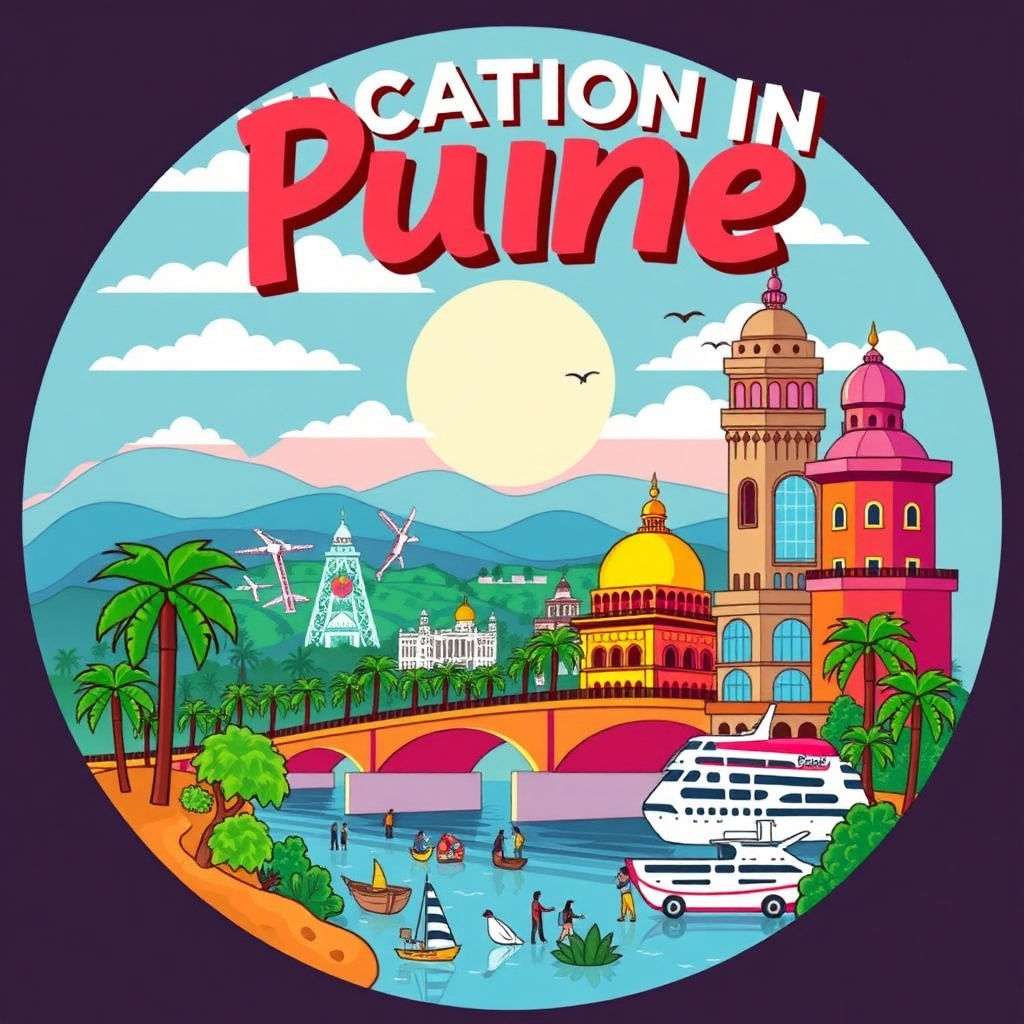

In [ ]:
image = free_artist("Pune")
display(image)

In [23]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [ ]:
def free_talker(message):
    response = pollinationsai.audio.speech.create(
      model="acestep",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content
4982

In [36]:
from IPython.display import Audio , display as d
audio = free_talker("Hello, welcome to FlightAI! How can I assist you today?")
#TODO play this audio in the notebook
d(Audio(audio, autoplay=True))


## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation 

I tried finding free alternatives i got one for image generation pollinations ai provides freee pollens/credits for completing quests they have model for image generation that can be used with pollens but no model for audio generation

2. Tool callling with database lookup

we made this in previous day itself but i still am not comfortable enough i would say with sql lite but ik what the functions written in this file does so it works

3. A step towards an Agentic workflow

this multimodel thing which runs in loop with multiple tools to help is called agentic ai 
llm generates tokens that can be used to interpret the direction of the work flow


In [24]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [25]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks


more about gradio we can customize gradio to our needs using gr.Blocks and gr.Rows to define individual rows and what they are meant for

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

In [ ]:

from openai import OpenAI
load_dotenv(override=True)
pollinations_api_key = os.getenv('POLLINATIONS_API_KEY')
# Correct client setup pointing to Pollinations text router
client = OpenAI(
    base_url="https://gen.pollinations.ai/v1",
    api_key=pollinations_api_key # Optional for free models
)

# Call chat completion using the image model name
image_response = client.images.generate(
    model="flux",
    prompt="A cozy cyber-punk coffee shop, rainy day, neon sign 'Code Here', 4k",
    n=1,
    size="1024x1024",
    response_format="b64_json"  # Options: "url" or "b64_json"
)

# The response content directly gives you the image URL string
image_b64 = image_response.data[0].b64_json
image_data = base64.b64decode(image_base64)
Image.open(BytesIO(image_data))

